## SafeDerm — 05. Pipeline

Wires the split CSVs (`02`), transforms (`04`), and a PyTorch `Dataset`/`DataLoader` together into something a model can actually train on.

The `Dataset` class lives in `src/dataset.py`, not here — same one-source-of-truth pattern as everything else. This notebook builds the three `Dataset` instances, wraps them in `DataLoader`s, and sanity-checks a batch before any modeling starts.

In [1]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.config import IMAGES_DIR, TRAIN_SPLIT_PATH, VAL_SPLIT_PATH, TEST_SPLIT_PATH
from src.dataset import SkinLesionDataset, IDX_TO_CLASS
from src.transforms import get_train_transforms, get_eval_transforms, IMAGENET_MEAN, IMAGENET_STD

BATCH_SIZE = 32

### Build datasets

Train uses augmentation. Val and test use eval-only transforms — no randomness, confirmed deterministic in `04_feature_engineering.ipynb`.

In [2]:
train_dataset = SkinLesionDataset(TRAIN_SPLIT_PATH, IMAGES_DIR, transform=get_train_transforms())
val_dataset = SkinLesionDataset(VAL_SPLIT_PATH, IMAGES_DIR, transform=get_eval_transforms())
test_dataset = SkinLesionDataset(TEST_SPLIT_PATH, IMAGES_DIR, transform=get_eval_transforms())

print(f"Train: {len(train_dataset)} images")
print(f"Val  : {len(val_dataset)} images")
print(f"Test : {len(test_dataset)} images")

Train: 6981 images
Val  : 1532 images
Test : 1502 images


### Wrap in DataLoaders

Only train shuffles — val/test order doesn't matter, and shuffling them would just waste compute.

In [3]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

Train batches: 219
Val batches  : 48
Test batches : 47


### Sanity check — pull one batch

Confirms shapes match what the model will expect, and that labels decode back to sensible class names.

In [4]:
images, labels = next(iter(train_loader))

print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")
print(f"Labels in this batch: {[IDX_TO_CLASS[int(l)] for l in labels]}")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Labels in this batch: ['nv', 'nv', 'nv', 'nv', 'nv', 'nv', 'nv', 'nv', 'mel', 'nv', 'nv', 'nv', 'nv', 'bkl', 'df', 'bkl', 'nv', 'mel', 'nv', 'bcc', 'nv', 'mel', 'nv', 'nv', 'bcc', 'bkl', 'nv', 'nv', 'bkl', 'bkl', 'akiec', 'nv']


### Visualize one batch

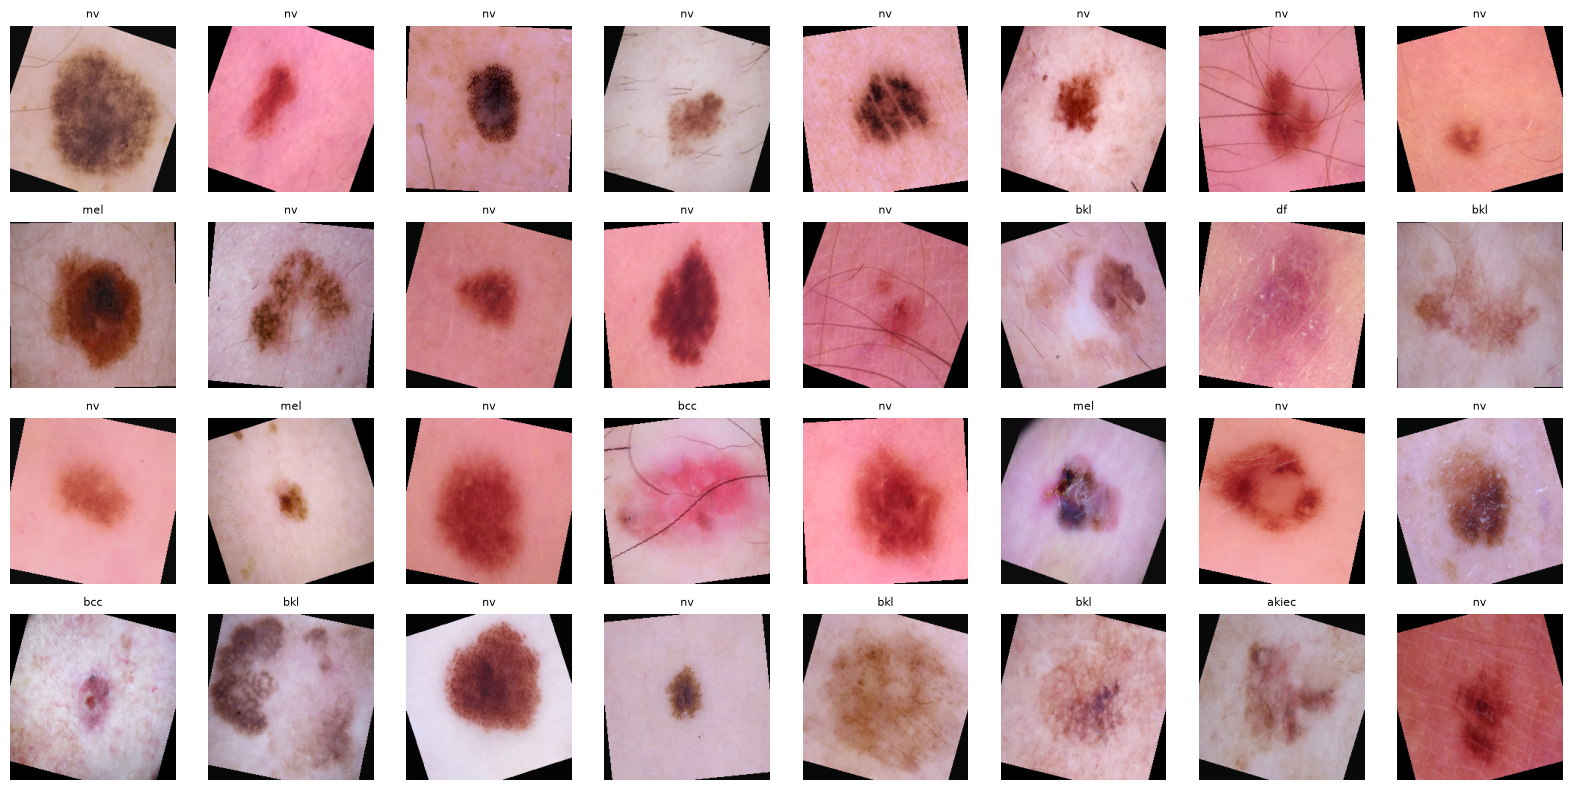

In [5]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i >= len(images):
        ax.axis("off")
        continue
    img = images[i].permute(1, 2, 0).numpy()
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = img.clip(0, 1)
    ax.imshow(img)
    ax.set_title(IDX_TO_CLASS[int(labels[i])], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Summary

- `Dataset`/`DataLoader` defined once in `src/dataset.py`; label encoding fixed by `ALL_CLASSES` order in `src/labels.py`.
- Train loader shuffles and augments; val/test do neither.
- Batch shapes and label decoding confirmed above.
- Next: `06_baseline_model.ipynb` — first real model, trained on this exact pipeline.